## Inteligență Artificială - Laboratorul 1 : Căutări
 - Tudor Berariu <tudor.berariu@gmail.com>
 - Andrei Olaru <cs@andreiolaru.ro>
 - Cătălin-Mihail Chiru <cata.chiru99@gmail.com>

### BAREM
* 1p `is_good`
* 1p `get_neighbors`
* 1p distanțe
* 5p implementare A*
* 1p refacere drum
* 1p implementarea funcționează bine pe ambele probleme

### Scopul laboratorului

De foarte multe ori problemele care sunt legate de domeniul inteligenței artificiale sunt abstractizate ca o **căutare în spațiul stărilor** problemei. Laboratorul de astăzi își propune să prezinte un algoritm de căutare informată: **A\***.

In [61]:
!pip install matplotlib


[notice] A new release of pip is available: 23.3.2 -> 26.0.1
[notice] To update, run: C:\Users\Andrei\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Problema

În cadrul acestui laborator vom rezolva 2 probleme:
* găsirea unui drum între două poziții pe o hartă bidimensională cu obstacole
* rezolvarea unui 8-puzzle

Problemele de căutare sunt în general abstractizate cu grafuri. Harta bidimensională poate fi văzută ca un graf neorientat în care fiecare nod corespunde unei celule de pe hartă, iar o muchie conectează nodurile corespunzătoare  unor celule adiacente.

Problema de tip 8-puzzle poate fi văzută ca un graf neorientat în care nodurile corespund posibilelor aranjări ale pieselor, iar muchiile conectează noduri între care se poate ajunge printr-o singură mutare legală.

#### Labirintul

In [1]:
# Vom reprezenta labirintul printr-un tablou bidimensional (o listă de liste)
# celulele libere vor avea valoarea 0, iar pereții valoarea 1

height = 10
width = 20

# Construim labirintul ca o listă de liste. 
# Prima coordonată este înălțimea, iar a doua coordonată este lungimea hărții
labyrinth = [[0 for c in range(width)] for r in range(height)] # Aici am creat un labirint gol, fără obstacole

# Așezăm câteva obstacole pe hartă
for r in range(2, 7):
    labyrinth[r][6] = 1
    labyrinth[6][r] = 1
labyrinth[2][7] = 1

In [2]:
# Punctul de plecare și punctul destinație vor fi reprezentate prin tupluri
start = (5, 5)
final = (8, 8)

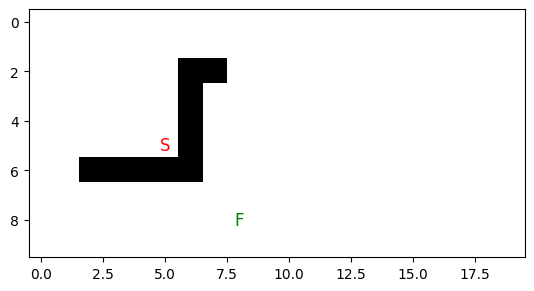

In [3]:
%matplotlib inline
import matplotlib.pyplot as pyplot
pyplot.imshow(labyrinth, cmap='Greys', interpolation='nearest') # Afișăm labirintul folosind o hartă de culori în tonuri de gri
pyplot.text(start[1], start[0], 'S', color='red', fontsize=12, ha='center', va='center') # Adăugăm un text 'S' pentru punctul de start, colorat în roșu
pyplot.text(final[1], final[0], 'F', color='green', fontsize=12, ha='center', va='center') # Adăugăm un text 'F' pentru punctul final, colorat în verde
pyplot.show() # Afișăm harta cu punctele de start și final evidențiate

In [33]:
is_final_labyrinth = lambda position: position == final # Funcție lambda care verifică dacă poziția dată este punctul final

assert list(map(is_final_labyrinth, [(1,1), (3, 6), (8, 8)])) == [False, False, True], "Eroare is_final_labyrinth" 
# Verificăm dacă funcția lambda funcționează corect pentru câteva poziții de test

### Algoritmul A* pentru labirint

Pentru a implementa algoritmul **A\*** trebuie să putem construi vecinii valizi ai unei stări.

In [4]:
# Scrieți o funcție care verifică dacă un tuplu dat reprezintă
# coordonatele unei poziții libere de pe hartă (coordonatele nu depășesc limitele hărții
# și acolo nu se găsește un obstacol)

def is_good(pos: tuple[int, int]) -> bool:
    """
    pos: tuple(int, int)
        Coordonatele unei celule de pe hartă în format (y, x)
    return: bool
        True dacă celula este liberă și nu depășește dimensiunile hărții
        False în caz contrar
    """
    # TODO
    # Verificam daca pozitia este in interiorul hartii
    y, x = pos # Desfacem tuplul în coordonate y și x; y reprezintă linia, iar x reprezintă coloana
    in_bounds = 0 <= y < height and 0 <= x < width # Verificăm dacă coordonatele sunt în limitele hărții; 
    # in_bounds va fi True dacă y este între 0 și height-1 și x este între 0 și width-1

    # Celula este buna doar daca este in limite si nu este obstacol
    if in_bounds and labyrinth[y][x] == 0:
        return True
    return False
    #/

assert [is_good(p) for p in [(-1,2), (height,3), (width,4), (5,5), (6,6)]] == [False, False, False, True, False], "is_good nu a fost implementată corect"
assert [is_good(p) for p in [(height-1, width-1), (width-1, height-1)]] == [True, False], "Ai inversat linia cu coloana în is_good"

In [8]:
# Scrieți o funcție care întoarce celulele vecine poziției date (doar cele libere)
# Vecinii se află la o distanță de o singură celulă pe orizontală sau verticală, fără diagonale.
# Folosiți funcționala filter și funcția is_good scrisă anterior

def get_neighbours_labyrinth(pos: tuple[int, int]) -> list[tuple[int, int]]:
    # La ce am nevoie de aceasta functie get_neighbours_labyrinth? Pentru a afla care sunt pozitiile vecine libere, astfel incat sa pot continua cautarea in labirint 
    
    """
    pos: tuple(int, int)
        Coordonatele unei celule de pe hartă în format (y, x)
    return: list(tuple(int, int))
        Lista cu coordonatele celulelor vecine libere
    """
    # TODO
    # Generam toate pozitiile vecine (sus, jos, stanga, dreapta)
    y, x = pos
    candidates = [(y - 1, x), (y + 1, x), (y, x - 1), (y, x + 1)]

    # Filtram doar vecinii valizi (in harta si fara obstacole)
    return list(filter(is_good, candidates))

# Assert without order
assert set(get_neighbours_labyrinth((0, 9))) == {(1, 9), (0, 8), (0, 10)}, "Unit test1: get_neighbours_labyrinth nu a fost implementată corect"
assert set(get_neighbours_labyrinth((5, 5))) == {(4, 5), (5, 4)}, "Unit test2: get_neighbours_labyrinth nu a fost implementată corect"

#### Funcții euristice

Implementați două funcții euristice pe care să le folosiți în algoritmul **A\***:
 - distanța euclidiană
 - distanța Manhattan

In [ ]:
from math import sqrt

## In C++ am /**/pentru a scrie comentarii pe mai multe linii. In Python am """
#. In Python am # TODO #/ pentru a marca locurile unde trebuie sa scriem codul.
"""
Care e diferenta dintre distanta Manhattan si distanta Euclidiana si ce reprezinta fiecare? Detaliaza fiecare distanta si da un exemplu pentru fiecare.

Distanta Manhattan, cunoscuta si sub numele de distanta L1, reprezinta suma valorilor absolute ale diferentelor dintre coordonatele a doua puncte. 
Aceasta distanta este utila in situatii in care deplasarea se face pe o grila, cum ar fi intr-un oras cu strazi perpendiculare. 

De exemplu, daca avem doua puncte A(1, 2) si B(4, 6), distanta Manhattan dintre ele ar fi |1-4| + |2-6| = 3 + 4 = 7.



Distanta Euclidiana, cunoscuta si sub numele de distanta L2, reprezinta lungimea segmentului de dreapta care leaga cele doua puncte in spatiul euclidian. 
Aceasta distanta este utila in situatii in care deplasarea se face in linie dreapta, cum ar fi intr-un spatiu deschis. 

De exemplu, daca avem aceleasi puncte A(1, 2) si B(4, 6), distanta Euclidiana dintre ele ar fi sqrt((1-4)^2 + (2-6)^2) = sqrt(9 + 16) = sqrt(25) = 5.



Si de ce am nevoie de distanta Euclidiana si distanta Manhattan in A*? Pentru a estima cat de departe suntem de destinatie, astfel incat sa putem alege calea care pare cea mai 
promitatoare. 
Distanta Euclidiana ne ofera o estimare a distantei reale intre doua puncte, ceea ce ne ajuta sa luam decizii informate in procesul de cautare. 

Distanta Manhattan, pe de alta parte, este utila in situatii in care deplasarea se face pe o grila, cum ar fi intr-un oras cu strazi perpendiculare. 
In astfel de cazuri, distanta Manhattan poate oferi o estimare mai precisa a distantei





[aqurăt] in engleza se scrie accurate = precisa, exacta, corecta, riguroasa, conforma cu realitatea, fara erori sau abateri.

Laborantul mi-a spus ca distanta Manhattan este mai accurate decat distanta Euclidiana in cazul in care deplasarea se face pe o grila, deoarece se 
ia in considerare doar miscarile pe orizontala si verticala, care sunt cele permise intr-un astfel de mediu.

In schimb, distanta Euclidiana poate fi mai accurate in situatii in care deplasarea se face in linie dreapta (se face in oblica), 
deoarece ofera o estimare a distantei reale intre doua puncte, fara a lua in considerare restrictiile de miscare.
"""

def euclidean_distance(a: tuple[int, int], b: tuple[int, int]) -> float:
    """
    a: tuple(int, int)
        Coordonatele primei celule de pe hartă pentru care se calculează distanța. 
        Formatul poziției este (y, x)
    b: tuple(int, int)
        Coordonatele celei dea doua celule de pe hartă pentru care se calculează distanța. 
        Formatul poziției este (y, x)
    return: float
        Distanța euclidiană dintre cele două celule
    """
    # Aplicam formula distantei euclidiene intre doua puncte ; Asta am scris eu, liniile astea doua
    return sqrt((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2) # a[0] reprezinta coordonata y a punctului a, iar a[1] reprezinta coordonata x a punctului a. Similar pentru b[0] si b[1].
    # ** reprezinta operatorul de exponentiere , adica ridicarea la putere, in Python, 
    # deci (a[0] - b[0]) ** 2 calculeaza patratul diferentei dintre coordonatele y ale punctelor a si b, iar (a[1] - b[1]) ** 2 
    # calculeaza patratul diferentei dintre coordonatele x ale punctelor a si b. Suma acestor doua valori este apoi trecuta ca argument la functia sqrt pentru a calcula 
    # distanta euclidiana.

    # De ce nu merge in loc de ** si ^? Pentru ca in Python, operatorul ^ este folosit pentru operatii bitwise XOR, nu pentru exponentiere.
    # Daca am incerca sa folosim ^ pentru a ridica la putere, am obtine un rezultat complet diferit, deoarece ar interpreta operatia ca o operatie bitwise intre 
    # numerele respective, in loc sa calculeze patratul diferentei dintre coordonate.
assert euclidean_distance((2,3), (4, 7)) == 4.47213595499958, "euclidean_distance nu a fost implementată corect"

In [18]:
def manhattan_distance_labyrinth(a: tuple[int, int], b: tuple[int, int]) -> float:
    """
    a: tuple(int, int)
        Coordonatele primei celule de pe hartă pentru care se calculează distanța. 
        Formatul poziției este (y, x)
    b: tuple(int, int)
        Coordonatele celei dea doua celule de pe hartă pentru care se calculează distanța. 
        Formatul poziției este (y, x)
    return: float
        Distanța Manhattan dintre cele două celule
    """
    # Distanța Manhattan este suma diferentelor absolute pe fiecare axa ; Asta am scris eu, liniile astea doua
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

assert manhattan_distance_labyrinth((2,3), (4,0)) == 5, "manhattan_distance_labyrinth nu a fost implementată corect"

#### Algoritmul A\*

Scrieți o funcție ce implementează algoritmul **A\***. Funcția va primi 6 argumente:
 - **start** - starea inițială
 - **end** - starea finală (necesară pentru apelul lui *h*
 - **h** - funcția euristică folosită
 - **neighbors** - funcția care obține vecinii unei stări
 - **is_final** - funcția care determină dacă o stare este finală
 - **print_state** - funcție pe care o puteți folosi pentru a afișa o stare
 
Frontiera va fi o coadă de priorități ce va conține nodurile descoperite. Prioritatea va fi dată de funcția de cost `f(n) = g(n) + h(n)` unde:
  - `g(n)` este costul real de la nodul de start până la nodul n
  - `h(n)` este costul estimat de la nodul n până la nodul final

Pentru informațiile ce trebuie memorate pentru fiecare nod descoperit vom folosi un dicționar în care reținem pentru  fiecare stare părintele și costul **g** de la starea inițială până la starea respectivă:

    disovered[node] = (cost_g, parent)
    

#### Cozi de priorități

Pentru coada de priorități necesară algoritmului **A\*** vom folosi heap-ul din Python [[1]](https://docs.python.org/3/library/heapq.html).

In [20]:
from heapq import heappop, heappush

# F e cat am mers pana acolo. F reprezinta costul de la punctul de start pana la punctul curent, iar H reprezinta estimarea distantei de la punctul curent pana la punctul final.
# G reprezinta costul total estimat de la punctul de start pana la punctul final, trecand prin punctul curent. G se calculeaza ca F + h.

priority_queue = []
heappush(priority_queue, (2, 'A'))
heappush(priority_queue, (1, 'B'))
heappush(priority_queue, (1.5, 'C'))

print(heappop(priority_queue))  # ==> (1, 'B')
print(heappop(priority_queue))  # ==> (1.5, 'C')
print(heappop(priority_queue))  # ==> (2, 'A')

(1, 'B')
(1.5, 'C')
(2, 'A')


In [21]:
def print_state_labyrinth(discovered, results, heuristic):
    g_cost_map = [[discovered[(r,c)][0] if (r,c) in discovered else 0 for c in range(width)]for r in range(height)]
    h_cost_map = [[heuristic((r,c), final) if labyrinth[r][c] == 0 else 0 for c in range(width)]for r in range(height) ]

    fig, axes = pyplot.subplots(1, 2, figsize=(12, 6))
    img = axes[0].imshow(g_cost_map, cmap='inferno', interpolation='nearest')
    axes[0].set_title('G-Cost')
    axes[1].imshow(h_cost_map, cmap='inferno', interpolation='nearest')
    axes[1].set_title('H-Cost')

    for ax in axes:
        # Marcăm poziția de start și cea finală
        ax.text(start[1], start[0], 'O', color='gray', ha='center', va='center')
        ax.text(final[1], final[0], 'X', color='gray', ha='center', va='center')

        # Marcăm parcursul pe drumul optim
        for p in results:
            if p != start and p != final:
                ax.text(p[1], p[0], '*', color='gray', ha='center', va='center')
    
    # Verifica daca se poate importa din mpl_toolkits
    try:
        from mpl_toolkits.axes_grid1 import make_axes_locatable
        
        # Adauga legenda fara a iesi din dimensiunea imaginii
        for ax in axes:
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.05)
            clb = pyplot.colorbar(img, cax=cax)
    except ImportError:
        # Set label on top of the colorbar
        for ax in axes:
            clb = pyplot.colorbar(img, orientation='vertical', fraction=0.05, pad=0.05)
            clb.set_label('G-Cost', labelpad=-30, y=1.08, rotation=0)

        
    pyplot.show()
    print(f"Path results: {results}")


In [30]:
from typing import Callable


def astar( # reprezintă funcția care implementează algoritmul A* pentru a găsi cel mai scurt drum într-un labirint reprezentat ca o matrice bidimensională.
        start: tuple[int, int], 
        end: tuple[int, int], 
        h: Callable[[tuple[int, int], tuple[int, int]], float], 
        neighbours: Callable[[tuple[int, int]], list[tuple[int, int]]], 
        is_final: Callable[[tuple[int, int]], bool], 
        print_state: Callable, 
        print_flag: bool = True
    ) -> tuple[list[tuple[int, int]], int]:
    """
    start: tuple(int, int)
        Poziția de start în labirint.
        Poziția este în format (y, x)
    end: tuple(int, int)
        Poziția de final în labirint.
        Poziția este în format (y, x)
    h: Callable[[tuple[int, int], tuple[int, int]], float]
        Funcția euristică
    neighbours: Callable[[tuple[int, int]], list[tuple[int, int]]]
        Funcția care obține lista de vecini a unei stări
    is_final: Callable[[tuple[int, int]], bool]
        Funcția care determină dacă o stare este finală
    print_state: Callable
        Funcția pentru vizualizarea stărilor
    should_print: bool, optional
        Flag pentru afișarea stărilor, default True
        
    return: tuple
        Un tuplu conținând (drumul_găsit, noduri_expandate)
    """
    # Frontiera, ca listă (heap) de tupluri (cost_f, nod)
    frontiera = [] # Aici am creat o lista goala care va reprezenta frontiera, adica multimea nodurilor care au fost descoperite dar nu au fost inca expandate.
    heappush(frontiera, (0 + h(start, end), start)) # Adaugam nodul de start in frontiera, cu costul f calculat ca fiind costul g (0) plus estimarea h de la start la end.

    """
    De ce am nevoie de costurile F, G si H la A*? Pentru ca
     - F reprezinta costul total estimat de la punctul de start pana la punctul final, trecand prin punctul curent. F se calculeaza ca G + H
     - G reprezinta costul de la punctul de start pana la punctul curent. G se calculeaza ca fiind costul de la start pana la parinte + 1 (costul de a face o miscare)
     - H reprezinta estimarea distantei de la punctul curent pana la punctul final, oferita de functia euristica. H ne ajuta sa luam decizii informate in procesul de cautare, oferind 
     o estimare a distantei reale intre doua puncte, fara a lua in considerare restrictiile de miscare.

    In A*, folosim F pentru a determina ordinea in care nodurile sunt expandate (expandat inseamna explorat), alegand intotdeauna nodul cu cel mai mic cost F. 
    G ne ajuta sa calculam costul real al drumului parcurs pana la nodul curent, iar H ne ofera o estimare a distantei ramase pana la destinatie, astfel incat sa putem alege calea 
    care pare cea mai promițătoare (cu costul f minim).

    (0 + h(start, end), start) reprezinta tuplul pe care il adaugam in frontiera, unde 0 este costul g de la start la start (deoarece nu am facut nicio miscare), iar h(start, end) 
    este estimarea distantei de la start la end oferita de functia euristica.
    Acest tuplu ne permite sa incepem cautarea cu nodul de start, avand un cost f care reflecta doar estimarea h, deoarece g este 0 la inceput.
    
    """
    
    # Nodurile descoperite ca dicționar nod -> (cost_g-până-la-nod, părinte)
    discovered = {start: (0, None)}

    while frontiera:
        # TODO
        # Scoatem nodul cu costul f minim
        current_f, current = heappop(frontiera) # heappop scoate si returneaza elementul cu costul f minim din frontiera, adica nodul care are cel mai mic cost estimat de la start la end, trecand prin el.
        # current_f reprezinta costul f al nodului curent, iar current reprezinta pozitia nodului curent in labirint (un tuplu de coordonate y, x).

        # Daca am ajuns la final, ne oprim
        if is_final(current):
            break

        current_g, _ = discovered[current] # Aici am extras costul g de la start pana la nodul curent din dicționarul discovered. _ reprezinta parintele nodului curent, 
        # dar nu avem nevoie de el in acest moment, asa ca il ignoram folosind _ .

        # Expandam vecinii
        for neigh in neighbours(current):
            tentative_g = current_g + 1 # tentative_g reprezinta costul de a ajunge la vecinul curent prin nodul curent.
            # Presupunem ca fiecare miscare are un cost de 1, deci adaugam 1 la costul g al nodului curent pentru a obtine costul g pentru vecin.

            # Daca vecinul nu e descoperit sau avem un drum mai bun
            if neigh not in discovered or tentative_g < discovered[neigh][0]:
                discovered[neigh] = (tentative_g, current) # Aici am actualizat dicționarul discovered pentru vecinul curent, setând costul g pentru vecin la tentative_g și 
                # parintele vecinului la nodul curent.
                f_cost = tentative_g + h(neigh, end) # Aici am calculat costul f pentru vecinul curent, adunand costul g (tentative_g) si estimarea h de la vecin la end oferita 
                # de functia euristica.
                heappush(frontiera, (f_cost, neigh)) # Adaugam vecinul in frontiera cu costul f calculat, astfel incat sa fie luat in considerare pentru expandare in iteratiile urmatoare.
        
    # Refacem drumul de la final la start folosindu-ne de dicționarul discovered
    path = []
    last_node = end

    # TODO
    # Vrem să păstrăm stările intermediare de la start la final
    # Daca finalul nu a fost descoperit, returnam lista goala
    if last_node not in discovered:
        path = []
    else:
        # Vrem să păstrăm stările intermediare de la start la final
        while last_node is not None:
            path.append(last_node)
            last_node = discovered[last_node][1]

    # Va trebui să întoarcem drumul în ordine inversă    
    # TODO
    # Va trebui să întoarcem drumul în ordine inversă    
    path.reverse()

    if print_flag:
        print_state(discovered, path)
    
    return path, len(discovered.keys()) # drumul, ca listă de poziții și numărul de stări descoperite

Pentru a ilustra influența funcției euristice asupra eficienței algorithmului **A\***, vom păstra într-un dicționar numărul de noduri expandate pentru fiecare funcție euristică:

In [31]:
heuristic_metrics_labyrinth = {}

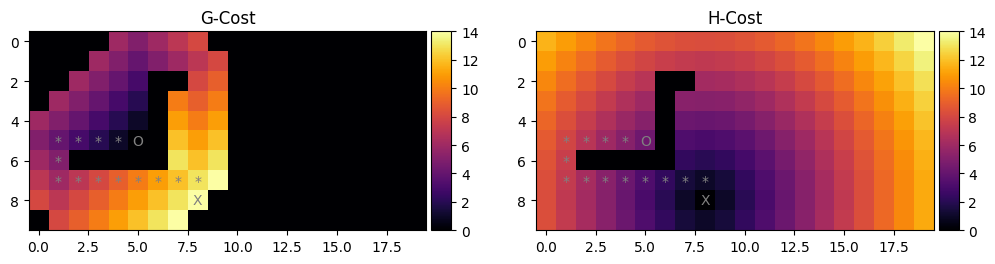

Path results: [(5, 5), (5, 4), (5, 3), (5, 2), (5, 1), (6, 1), (7, 1), (7, 2), (7, 3), (7, 4), (7, 5), (7, 6), (7, 7), (7, 8), (8, 8)]


In [36]:
heuristic_metrics_labyrinth['euclidean'] =  astar(start, final, euclidean_distance, get_neighbours_labyrinth, is_final_labyrinth, lambda x, y: print_state_labyrinth(x, y, euclidean_distance))

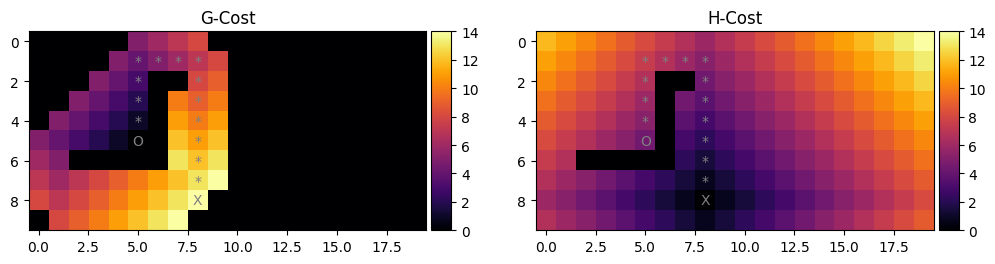

Path results: [(5, 5), (4, 5), (3, 5), (2, 5), (1, 5), (1, 6), (1, 7), (1, 8), (2, 8), (3, 8), (4, 8), (5, 8), (6, 8), (7, 8), (8, 8)]


In [37]:
heuristic_metrics_labyrinth['manhattan'] =  astar(start, final, manhattan_distance_labyrinth, get_neighbours_labyrinth, is_final_labyrinth, lambda x, y: print_state_labyrinth(x, y, manhattan_distance_labyrinth))

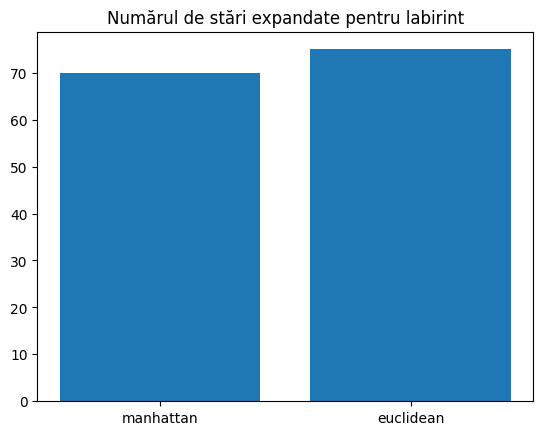

In [38]:
def barplot_number_of_expanded_nodes(heuristic_metrics, task_name):
    plot_metrics = [(key, value[1]) for key, value in heuristic_metrics.items()]
    plot_metrics.sort(key=lambda x: x[1])

    names = [x[0] for x in plot_metrics]
    values = [x[1] for x in plot_metrics]

    pyplot.bar(range(len(names)), values, align='center')
    pyplot.xticks(range(len(names)), names)
    pyplot.title(f'Numărul de stări expandate pentru {task_name}')
    pyplot.show()
barplot_number_of_expanded_nodes(heuristic_metrics_labyrinth, 'labirint')
# Observăm că distanța Manhattan este mai eficientă decât distanța euclidiană, pentru explorarea labirintului.

### A-star pentru un joc de tip 8-puzzle

Propunem rezolvarea jocului $n^2 - 1$ tiles folosind algoritmul A*.

Want to [know](https://en.wikipedia.org/wiki/15_Puzzle) [more](https://github.com/jussihyva/n-puzzle/blob/master/README.md)

In [39]:
import numpy as np

Ne vom folosi de matplotlib pentru a afișa starea curentă a jocului, sub forma unei imagini.

In [40]:
no_tiles = 8

size = int(np.sqrt(no_tiles+1))

In [41]:
img = pyplot.imread('./eminescu.jpg')
img = np.array(img)
img.shape # dimensiunea și numărul de canale de culoare

(1126, 800, 3)

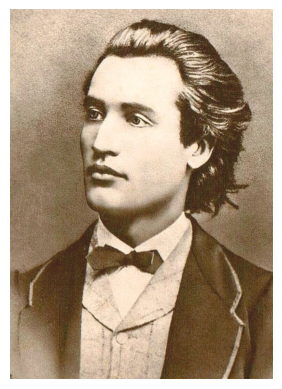

In [42]:
pyplot.imshow(img)
pyplot.axis('off')
pyplot.show()

3 tiles


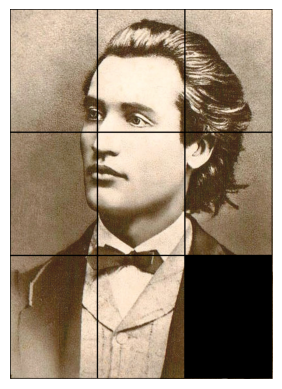

In [43]:
def create_borders(image, thickness, start_height, end_height, start_width, end_width):
    # Desenam chenarul fiecarui tile
    image[start_height:start_height + thickness, start_width:end_width] = 0
    image[end_height - thickness:end_height, start_width:end_width] = 0

    image[start_height:end_height, start_width:start_width + thickness] = 0
    image[start_height:end_height, end_width - thickness:end_width] = 0

    return image

# Vom împărți imaginea în n^2 părți egale și vom face ultimul pătrat negru
def break_image_into_tiles(image, no_tiles, thickness=2):
    tiles = []
    tile_size = np.sqrt(no_tiles + 1).astype(int)
    print(tile_size, "tiles")
    i = 0
    tile_height, max_height = image.shape[0] // tile_size, image.shape[0] - 1
    tile_width, max_width = image.shape[1] // tile_size, image.shape[1] - 1

    for r in range(tile_size):
        for c in range(tile_size):
            # Border around each tile
            start_height, end_height = r * tile_height, min((r + 1) * tile_height, max_height)
            start_width, end_width = c * tile_width, min((c + 1) * tile_width, max_width)

            image = create_borders(image, thickness, start_height, end_height, start_width, end_width)
            
            tiles.append(image[start_height:end_height, start_width:end_width])

            # Eliminam chenarul pentru tile-ul final
            if i == no_tiles:
                image[start_height:end_height, start_width:end_width] = 0
                break
            i += 1

    return tiles, image

tiles, image = break_image_into_tiles(img, no_tiles)
pyplot.imshow(img)
pyplot.axis('off')
pyplot.show()

Miscari posibile:
1. Jos (Spațiul gol se mută în sus)
2. Sus (Spațiul gol se mută în jos)
3. Dreapta (Spațiul gol se mută în stânga)
4. Stânga (Spațiul gol se mută în dreapta)

In [44]:
UP, DOWN, LEFT, RIGHT = 1, 2, 3, 4
debugging_mutari_celula_goala = {UP: 'sus', DOWN: 'jos', LEFT: 'stanga', RIGHT: 'dreapta'}

* Vom folosi în logica internă a puzzle-ului n-tiles o reprezentare a stării sub forma unei matrici de dimensiune n x n, în care fiecare element reprezintă o piesă a puzzle-ului. Spațiul gol va fi reprezentat de valoarea n^2 - 1.

* Ne folosim de biblioteca numpy pentru a manipula matricile mai ușor.

* Vom expune starea curentă a jocului sub forma unui tuplu. Avem nevoie de serializarea stării pentru a o putea folosi în dicționarul de descoperiri și în coada de priorități.

* Pentru a printa evoluția puzzle-ului, vom mapa tuplul/matricea stării curente peste imaginea inițială a puzzle-ului.

In [45]:
final_state_ntiles = tuple(range(no_tiles + 1))

In [46]:
def serialize_state(state):
    ''' Transformă starea din numpy array într-un tuplu de numere întregi '''
    return tuple(state.flatten())

def deserialize_state(serialized_state):
    ''' Transformă starea dintr-un tuplu de numere întregi într-un numpy array '''
    size = int(np.sqrt(len(serialized_state)))
    deserialize_state = np.array(serialized_state)
    return deserialize_state.reshape(size, size)

serialize_state(deserialize_state(final_state_ntiles))

(0, 1, 2, 3, 4, 5, 6, 7, 8)

In [47]:
def tuple_where(state, no_tiles, size):
    ''' Echivalentul np.where pentru a găsi rândul și coloana unde se află poziția golului '''

    idx = state.index(no_tiles)

    return idx // size, idx % size

In [60]:
tuple_where(final_state_ntiles, no_tiles=no_tiles, size=size) # ==> (2, 2)

(2, 2)

In [48]:
initial_state = serialize_state(np.array([[2, 4, 3], [5, 8, 6], [7, 1, 0]]))

In [49]:
# O stare a jocului va fi reprezentată de o matrice (parsată ca tuplu) de dimensiune n x n
# Mișcările posibile indică direcția în care se poate deplasa spațiul gol
def valid_moves(state, size):
    no_tiles = max(state)

    row, col = tuple_where(state, no_tiles, size)
    
    height, width = size, size
    # print(row, col)

    moves = []

    if row > 0: moves.append(UP)
    if row < height - 1: moves.append(DOWN)
    if col > 0: moves.append(LEFT)
    if col < width - 1: moves.append(RIGHT)
    return moves

valid_moves(serialize_state((np.array([[0, 1, 2], [3, 7, 4], [6, 8, 5]]))), 3) # ==> [1, 3, 4]

[1, 3, 4]

In [61]:
state = np.array([[0, 1, 2], [3, 7, 4], [6, 8, 5]])

# Mișcă spațiu gol în direcția specificată
def apply_move(state, move, size):
    no_tiles = max(state)

    row, col = tuple_where(state, no_tiles, size)

    idx = row * size + col

    state = list(state)

    if move == UP: state[idx], state[idx - size] = state[idx - size], state[idx]
    elif move == DOWN: state[idx], state[idx + size] = state[idx + size], state[idx]
    elif move == LEFT: state[idx], state[idx - 1] = state[idx - 1], state[idx]
    elif move == RIGHT: state[idx], state[idx + 1] = state[idx + 1], state[idx]

    state = tuple(state)
    return state

apply_move(serialize_state(state), 1, 3)  # ==> (0, 1, 2, 3, 8, 4, 6, 7, 5)

(0, 1, 2, 3, 8, 4, 6, 7, 5)

In [51]:
def get_neighbours_ntiles(state, size):
    return [apply_move(state, move, size) for move in valid_moves(state, size)]

def neighbours_ntiles(state):
    return get_neighbours_ntiles(state, size)

get_neighbours_ntiles(serialize_state(state), 3) # ==> [(0, 1, 2, 3, 8, 4, 6, 7, 5), (0, 1, 2, 3, 7, 4, 8, 6, 5),  (0, 1, 2, 3, 7, 4, 6, 5, 8)]

[(0, 1, 2, 3, 8, 4, 6, 7, 5),
 (0, 1, 2, 3, 7, 4, 8, 6, 5),
 (0, 1, 2, 3, 7, 4, 6, 5, 8)]

In [62]:
def generate_valid_shuffle(state, no_moves, seed=0):

    np.random.seed(seed)

    complementary_moves = {1: 2, 2: 1, 3: 4, 4: 3}

    size = int(np.sqrt(len(state)))

    possible_moves = valid_moves(state, size)

    # print(list(map(lambda x: debugging_mutari_celula_goala[x], possible_moves)))

    picked_move = np.random.choice(possible_moves, 1)[0]

    apply_move(state, picked_move, size)

    for i in range(no_moves - 1):
        # Evităm mutările care ar anula mutarea anterioară
        complementary_move = complementary_moves[picked_move]
        possible_moves = valid_moves(state, size)
        possible_moves = list(filter(lambda x: x != complementary_move, possible_moves))

        picked_move = np.random.choice(possible_moves, 1)[0]

        # Aplicăm mutarea
        state = apply_move(state, picked_move, size)

    return state

state = generate_valid_shuffle(final_state_ntiles, 1000)
state

(5, 8, 2, 3, 6, 1, 0, 7, 4)

In [63]:
def is_final_ntiles(state):
    size = len(state)
    gt = tuple(range(size))
    return state == gt

is_final_ntiles(serialize_state(np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8]])))  # ==> True

True

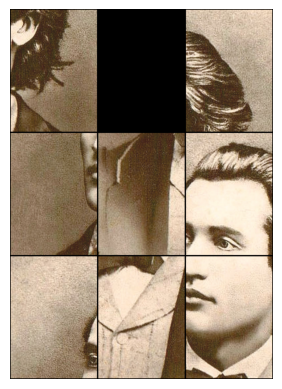

In [64]:
def print_tiles(state, tiles, plot_flag=True):
    size = int(np.sqrt(len(state)))
    new_image = np.zeros((size * tiles[0].shape[0], size * tiles[0].shape[1], 3), dtype=np.uint8)

    for r in range(size):
        for c in range(size):
            tile = tiles[state[r * size + c]]
            new_image[r * tile.shape[0]:(r + 1) * tile.shape[0], c * tile.shape[1]:(c + 1) * tile.shape[1]] = tile
    
    if plot_flag:
        pyplot.axis('off')
        pyplot.imshow(new_image)
        pyplot.show()
    return new_image

def print_state_ntiles(tiles):
    def actual_print(_, results):
        length = len(results)

        print(f"Soluția are {length} de mișcări")

        imgs_per_row = int(length // 3) + 1
        imgs_per_column = (length // imgs_per_row) + 1
        fig, axes = pyplot.subplots(imgs_per_column, imgs_per_row, figsize=(14, 7))

        fig.tight_layout()
        pyplot.subplots_adjust(hspace=0.001, wspace=0.2)

        for i, state in enumerate(results):
            new_img = print_tiles(state, tiles, plot_flag=False)
            ax = axes[i // imgs_per_row, i % imgs_per_row]
            ax.imshow(new_img)
            ax.axis('off')

        for i in range(length, imgs_per_row * (length // imgs_per_row + 1)):
            ax = axes[i // imgs_per_row, i % imgs_per_row]
            ax.axis('off')



        # for state in results: print_tiles(state, tiles)
    return actual_print

new_img = print_tiles(state, tiles)

# Funcții euristice

In [65]:
def manhattan_distance_ntiles(state_position, final_position):
    max_length = len(state_position)
    _size = size
    
    distance = 0

    for i in range(max_length):
        state_row, state_col = tuple_where(state_position, i, _size)
        final_row, final_col = tuple_where(final_position, i, _size)

        distance += abs(state_row - final_row) + abs(state_col - final_col)

    return distance

def absolute_distance_ntiles(state, final):
    return np.sum(np.abs(deserialize_state(state) - deserialize_state(final)))


def right_place_ntiles(state, final):
    return min(sum([1 for i in range(len(state)) if state[i] != final[i]]), len(final) - 1)

# manhattan_distance_ntiles(state, final_state_ntiles)
# absolute_distance_ntiles(state, final_state_ntiles)

In [58]:
heuristic_metrics_ntiles = {}

Soluția are 24 de mișcări


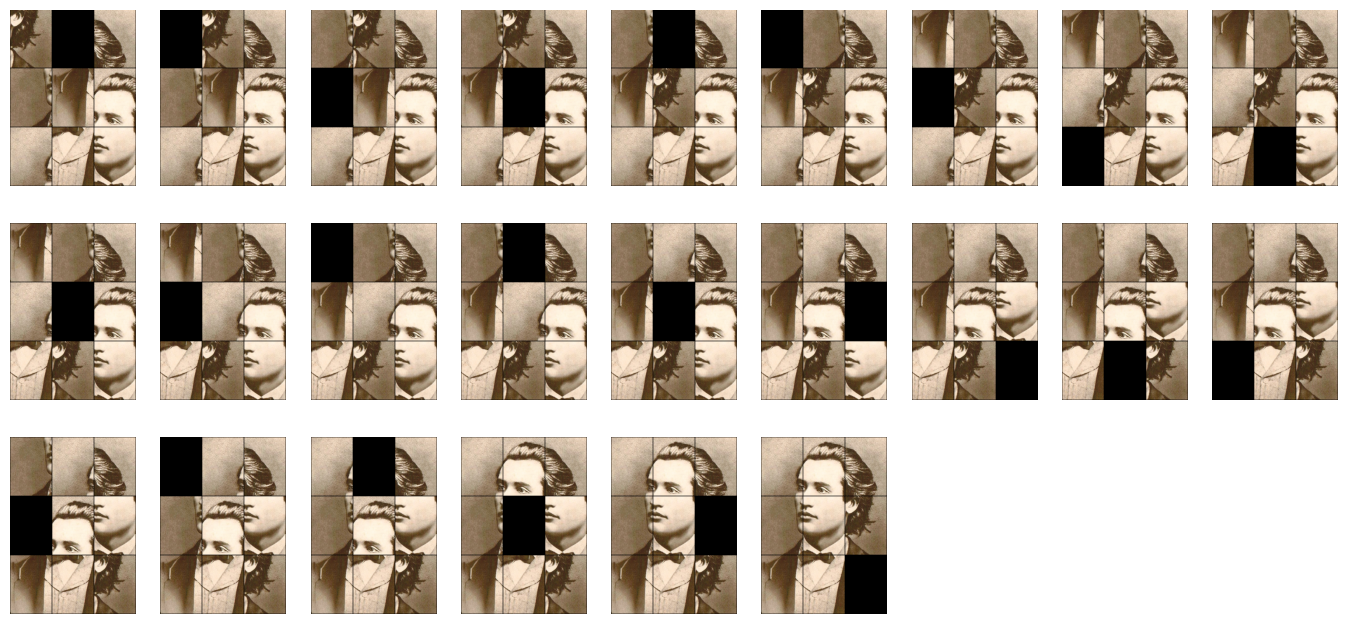

In [66]:
heuristic_metrics_ntiles['manhattan'] = astar(state, final_state_ntiles, manhattan_distance_ntiles, neighbours_ntiles, is_final_ntiles, print_state_ntiles(tiles))

Soluția are 24 de mișcări


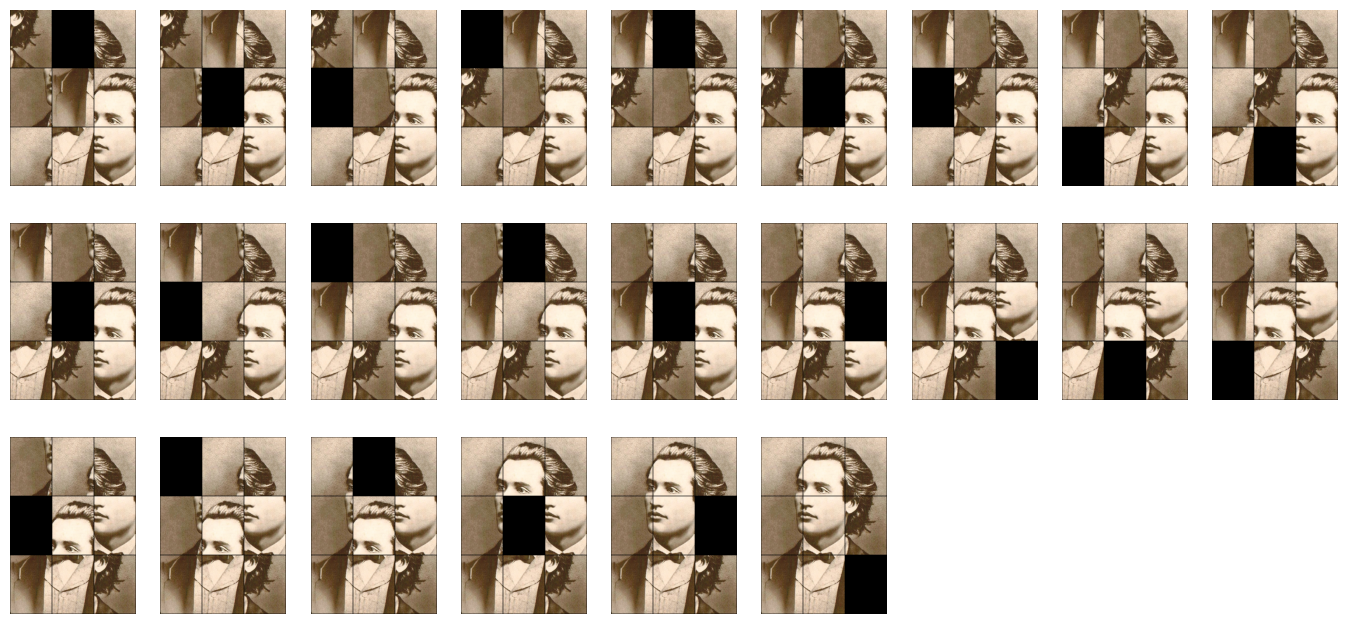

In [67]:
heuristic_metrics_ntiles['rightplace'] =  astar(state, tuple(range(no_tiles + 1)), right_place_ntiles, neighbours_ntiles, is_final_ntiles, print_state_ntiles(tiles))

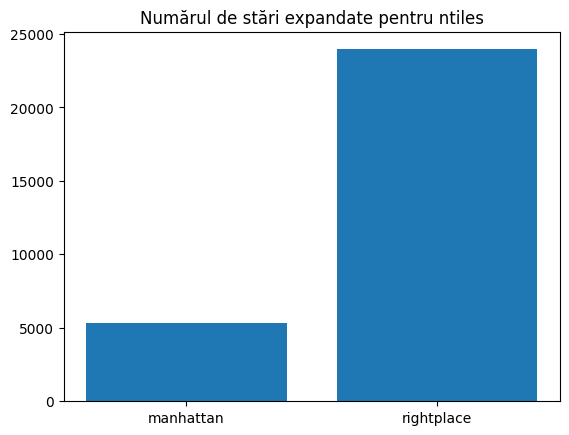

In [69]:
barplot_number_of_expanded_nodes(heuristic_metrics_ntiles, 'ntiles')

Putem observa că euristica rightplace este mult mai slabă decât euristica manhattan pentru N-Tiles

In [70]:
# Pe baza testarii unui număr redus de stări inițiale, vedem că nu există o diferență semnificativă între cele două euristici.
# Rulăm pentru un număr mai mare de stări inițiale pentru a observa diferențele.

def strip_name_from_anon_heuristic(name):
    return str(name).split(' ')[1].split('_')[0]

def run_multiple_states(final_state_ntiles, heuristics, neighbours, is_final, print_state, no_games):
    metrics_per_heuristic = {strip_name_from_anon_heuristic(h) : (h, []) for h in heuristics}

    # Generăm seedurile pentru stările inițiale
    seeds = np.arange(no_games * 100)

    np.random.shuffle(seeds)
    seeds = seeds[:no_games]

    print_step = no_games // 10

    for (i, seed) in enumerate(seeds):

        if (i + 1) % print_step == 0:
            print(f"Running game {i + 1} out of {no_games}")

        state = generate_valid_shuffle(final_state_ntiles, 1000, seed)
        for h_name in metrics_per_heuristic:
            h, results = metrics_per_heuristic[h_name]
            results.append(astar(state, final_state_ntiles, h, neighbours, is_final, print_state, False)[1])

    metrics_per_heuristic = {name: (name, np.mean(results)) for name, (_, results) in metrics_per_heuristic.items()}

    return metrics_per_heuristic

Dacă comparăm însă manhattan cu absolute, o euristică mult mai apropiată, vom vedea că avem nevoie de un număr mai mare de rulări pentru a determina care dintre cele 2 este mai bună: 

Pentru cazul în care rulăm o singură dată, sunt dăți în care Absolute este mai bună, iar altele în care Manhattan este mai bună, în funcție de starea inițială din care pornim. 

Rulând de mai multe ori, din configurații inițiale diferite, putem trage niște concluzii mai stabile din punctul de vedere al influenței deviației statistice.

Running game 5 out of 50
Running game 10 out of 50
Running game 15 out of 50
Running game 20 out of 50
Running game 25 out of 50
Running game 30 out of 50
Running game 35 out of 50
Running game 40 out of 50
Running game 45 out of 50
Running game 50 out of 50
Results for 50 games:  ('manhattan', 2435.32) ('absolute', 2785.02)


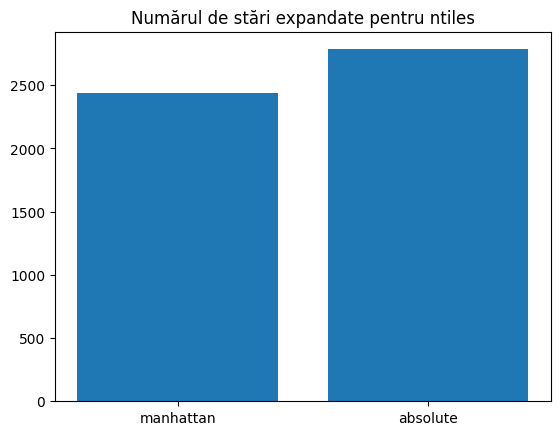

In [71]:
# Rulați pentru 50 de stări inițiale
# Pe baza barplot-ului generat, ar trebui să observați că distanța Manhattan este mai eficientă decât distanța absolută din perspectiva numărului de stări expandate.
heuristic_metrics_ntiles_50games = run_multiple_states(final_state_ntiles, [manhattan_distance_ntiles, absolute_distance_ntiles], neighbours_ntiles, is_final_ntiles, print_state_ntiles(tiles), 50)

print("Results for 50 games: ", *list(heuristic_metrics_ntiles_50games.values()))

barplot_number_of_expanded_nodes(heuristic_metrics_ntiles_50games, 'ntiles')

Running game 10 out of 100
Running game 20 out of 100
Running game 30 out of 100
Running game 40 out of 100
Running game 50 out of 100
Running game 60 out of 100
Running game 70 out of 100
Running game 80 out of 100
Running game 90 out of 100
Running game 100 out of 100
Results for 100 games:  ('manhattan', 3250.95) ('absolute', 3287.79)


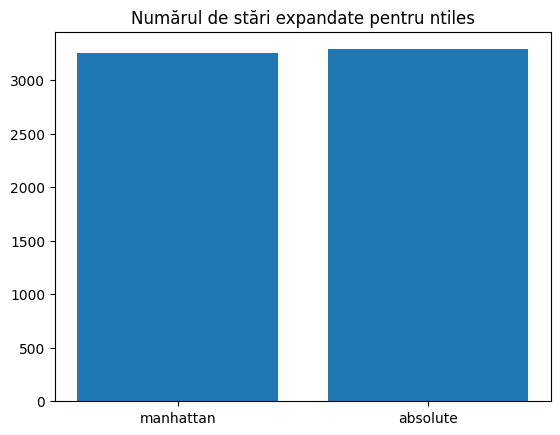

In [ ]:
 # heuristic_metrics_ntiles_100games1 = run_multiple_states(final_state_ntiles, [manhattan_distance_ntiles, absolute_distance_ntiles], neighbours_ntiles, is_final_ntiles, print_state_ntiles(tiles), 100)

 # print("Results for 100 games: ", *list(heuristic_metrics_ntiles_100games1.values()))

 # barplot_number_of_expanded_nodes(heuristic_metrics_ntiles_100games1, 'ntiles')

Running game 10 out of 100
Running game 20 out of 100
Running game 30 out of 100
Running game 40 out of 100
Running game 50 out of 100
Running game 60 out of 100
Running game 70 out of 100
Running game 80 out of 100
Running game 90 out of 100
Running game 100 out of 100
Results for 100 games:  ('manhattan', 2699.89) ('absolute', 2785.61)


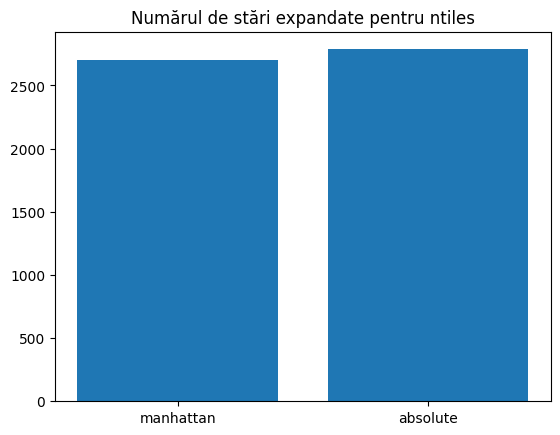

In [73]:
heuristic_metrics_ntiles_100games2 = run_multiple_states(final_state_ntiles, [manhattan_distance_ntiles, absolute_distance_ntiles], neighbours_ntiles, is_final_ntiles, print_state_ntiles(tiles), 100)

print("Results for 100 games: ", *list(heuristic_metrics_ntiles_100games2.values()))

barplot_number_of_expanded_nodes(heuristic_metrics_ntiles_100games2, 'ntiles')

Running game 100 out of 1000
Running game 200 out of 1000
Running game 300 out of 1000
Running game 400 out of 1000
Running game 500 out of 1000
Running game 600 out of 1000
Running game 700 out of 1000
Running game 800 out of 1000
Running game 900 out of 1000
Running game 1000 out of 1000
Results for 1000 games:  ('manhattan', 2856.423) ('absolute', 3015.787)


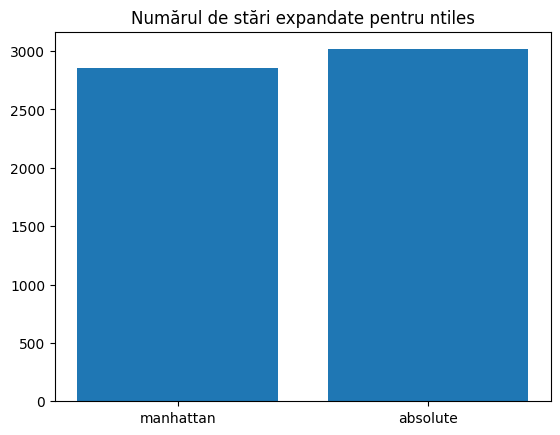

In [ ]:
# heuristic_metrics_ntiles_1000games = run_multiple_states(final_state_ntiles, [manhattan_distance_ntiles, absolute_distance_ntiles], neighbours_ntiles, is_final_ntiles, print_state_ntiles(tiles), 1000)

# print("Results for 1000 games: ", *list(heuristic_metrics_ntiles_1000games.values()))

# barplot_number_of_expanded_nodes(heuristic_metrics_ntiles_1000games, 'ntiles')

Running game 100 out of 1000
Running game 200 out of 1000
Running game 300 out of 1000
Running game 400 out of 1000
Running game 500 out of 1000
Running game 600 out of 1000
Running game 700 out of 1000
Running game 800 out of 1000
Running game 900 out of 1000
Running game 1000 out of 1000
Results for 1000 games:  ('manhattan', 2776.702) ('right', 19967.975)


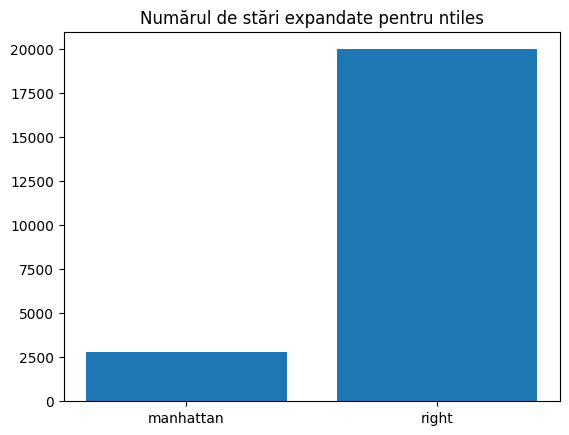

In [58]:
heuristic_metrics_ntiles_1000games2 = run_multiple_states(final_state_ntiles, [manhattan_distance_ntiles, right_place_ntiles], neighbours_ntiles, is_final_ntiles, print_state_ntiles(tiles), 1000)

print("Results for 1000 games: ", *list(heuristic_metrics_ntiles_1000games2.values()))

barplot_number_of_expanded_nodes(heuristic_metrics_ntiles_1000games2, 'ntiles')